In [1]:
import numpy as np
import gymnasium as gym
import matplotlib.pyplot as plt

In [7]:
NUM_EPISODES = 100000
EPSILON = np.linspace(0.9, 0.1, NUM_EPISODES)
DISCOUNT = 0.9
ALPHA = 0.1

In [ ]:
def train(env):
    obs_dim = env.observation_space.n
    act_dim = env.action_space.n

    Q = np.zeros((obs_dim, act_dim))
    reward_history = []

    for i, eps in enumerate(EPSILON):
        done = False
        total_reward = 0
        state, info = env.reset()
        action = np.argmax(Q[state]) if np.random.rand() > eps else env.action_space.sample()

        while not done:
            next_state, reward, terminated, truncated, info = env.step(action)
            next_action = np.argmax(Q[next_state]) if np.random.rand() > eps else env.action_space.sample()
            
            Q[state, action] += ALPHA * (
                reward + DISCOUNT * max(Q[next_state]) - Q[state, action]
            )

            total_reward += reward

            state = next_state
            action = next_action
            done = terminated or truncated

        reward_history.append(total_reward)

        # if not (i + 1) % 1000:
        #     print(f"Episode: {i+1}/{NUM_EPISODES}, Total reward: {total_reward}")

    return Q, reward_history

# Stochastic Environment

In [ ]:
env = gym.make("CliffWalking-v1", is_slippery=True)
Q, reward_history = train(env)

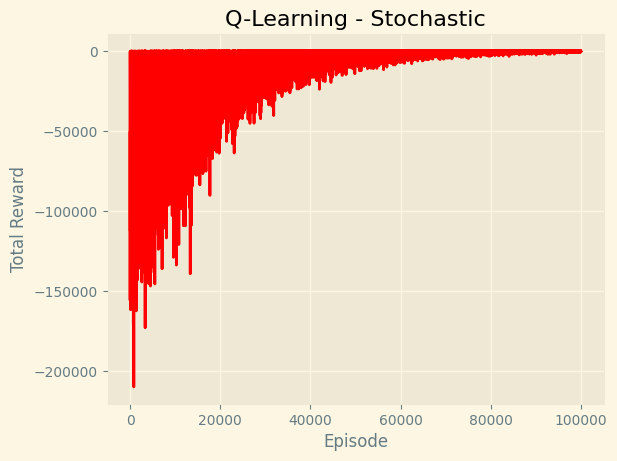

In [ ]:
reward_history = np.load("../experiments/ql_stochastic_rh.npy")
plt.style.use("Solarize_Light2")
plt.plot(reward_history, color="red")
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.title("Q-Learning - Stochastic")
plt.show()

In [ ]:
np.save('../experiments/ql_stochastic_rh.npy', reward_history)
np.save('../experiments/ql_stochastic_q.npy', Q)

# Deterministic Environment

In [ ]:
env = gym.make("CliffWalking-v1", is_slippery=False)
Q, reward_history = train(env)

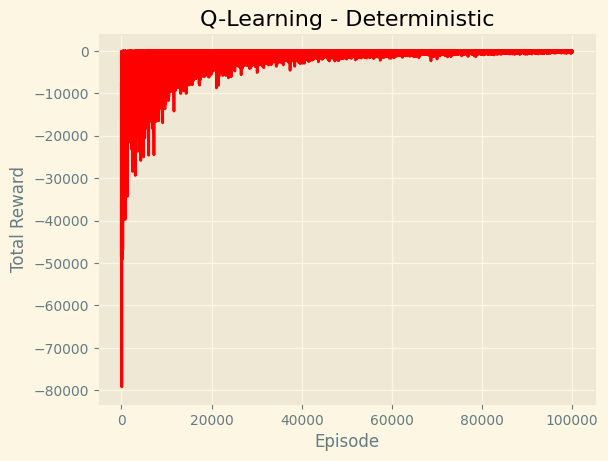

In [ ]:
reward_history = np.load("../experiments/ql_deterministic_rh.npy")
plt.style.use("Solarize_Light2")
plt.plot(reward_history, color="red")
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.title("Q-Learning - Deterministic")
plt.show()

In [ ]:
np.save('../experiments/ql_deterministic_rh.npy', reward_history)
np.save('../experiments/ql_deterministic_q.npy', Q)

# Evaluation

In [ ]:
Q = np.load("../experiments/ql_deterministic_q.npy")

In [3]:
eval_env = gym.make("CliffWalking-v1", is_slippery=False, render_mode="human")

observation, info = eval_env.reset(seed=42)
terminated = False
while not terminated:
    action = np.argmax(Q[observation])
    observation, reward, terminated, truncated, info = eval_env.step(action)

    if truncated:
        observation, info = eval_env.reset()

eval_env.close()

# Comparing with SARSA and Monte Carlo

In [46]:
def running_mean_cumsum(x, N=1000):
    cumsum = np.cumsum(np.insert(x, 0, 0)) 
    return (cumsum[N:] - cumsum[:-N]) / float(N)

In [ ]:
ql_rewards = running_mean_cumsum(np.load("../experiments/ql_stochastic_rh.npy"))
sa_rewards = running_mean_cumsum(np.load("../experiments/sarsa_stochastic_rh.npy"))
mc_rewards = running_mean_cumsum(np.load("../experiments/mc_stochastic_rh.npy"))

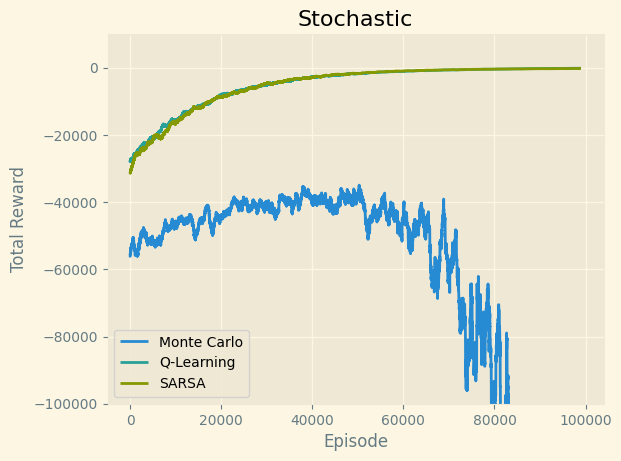

In [61]:
plt.style.use("Solarize_Light2")
plt.plot(mc_rewards, label="Monte Carlo")
plt.plot(ql_rewards, label="Q-Learning")
plt.plot(sa_rewards, label="SARSA")
plt.ylim(-100000, 10000)
plt.legend()
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.title("Stochastic")
plt.show()

In [ ]:
ql_rewards = running_mean_cumsum(np.load("../experiments/ql_deterministic_rh.npy"))
sa_rewards = running_mean_cumsum(np.load("../experiments/sarsa_deterministic_rh.npy"))
mc_rewards = running_mean_cumsum(np.load("../experiments/mc_deterministic_rh.npy"))

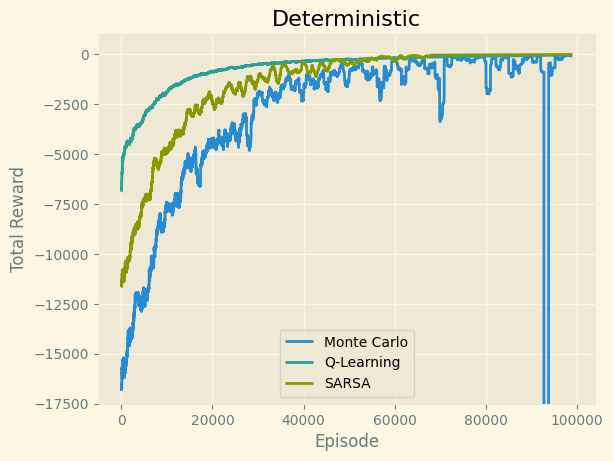

In [63]:
plt.style.use("Solarize_Light2")
plt.plot(mc_rewards, label="Monte Carlo")
plt.plot(ql_rewards, label="Q-Learning")
plt.plot(sa_rewards, label="SARSA")
plt.ylim(-17500, 1000)
plt.legend()
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.title("Deterministic")
plt.show()

In [66]:
def plot_q_values_map(q_table, shape=(4, 12)):
    # 1. Calculate State Values V(s) = max(Q(s, a))
    v_values = np.max(q_table, axis=1).reshape(shape)
    
    # 2. Get Best Actions (Policy)
    best_actions = np.argmax(q_table, axis=1).reshape(shape)
    
    fig, ax = plt.subplots(figsize=(12, 5))
    
    # 3. Plot Heatmap (State Values)
    # Use 'magma' or 'viridis' for high-contrast heatmaps
    im = ax.imshow(v_values, cmap='magma', interpolation='nearest')
    fig.colorbar(im, label='State Value (V)')

    # 4. Plot Arrows (Policy)
    # Action mapping: 0:Up, 1:Right, 2:Down, 3:Left
    dx = [0, 0.45, 0, -0.45]
    dy = [-0.45, 0, 0.45, 0] # Matplotlib y-axis is inverted
    
    for y in range(shape[0]):
        for x in range(shape[1]):
            # Skip arrows for Cliff and Goal (Terminal states)
            if y == 3 and 0 < x < 11: continue # Cliff
            if y == 3 and x == 11: continue    # Goal
            
            action = best_actions[y, x]
            ax.arrow(x, y, dx[action], dy[action], 
                     head_width=0.15, head_length=0.15, fc='white', ec='white')

    ax.set_title("CliffWalking: State Values (Heatmap) & Optimal Policy (Arrows)")
    plt.xticks(range(12))
    plt.yticks(range(4))
    plt.show()

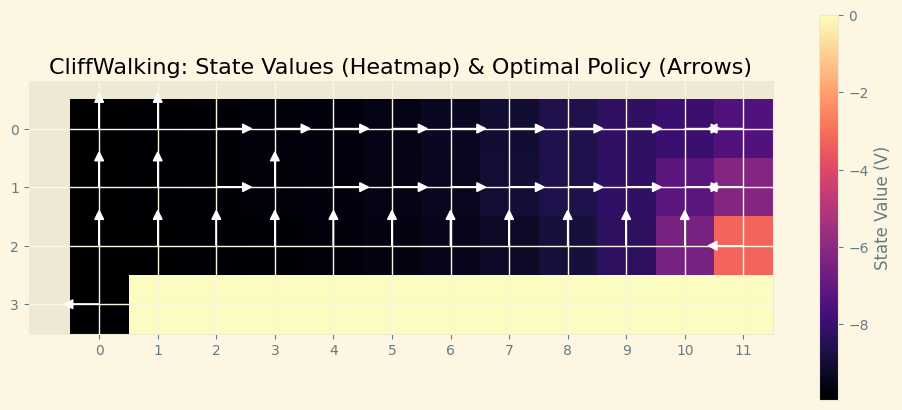

In [67]:
ql_stochastic_q = np.load("../experiments/ql_stochastic_q.npy")
plot_q_values_map(ql_stochastic_q)

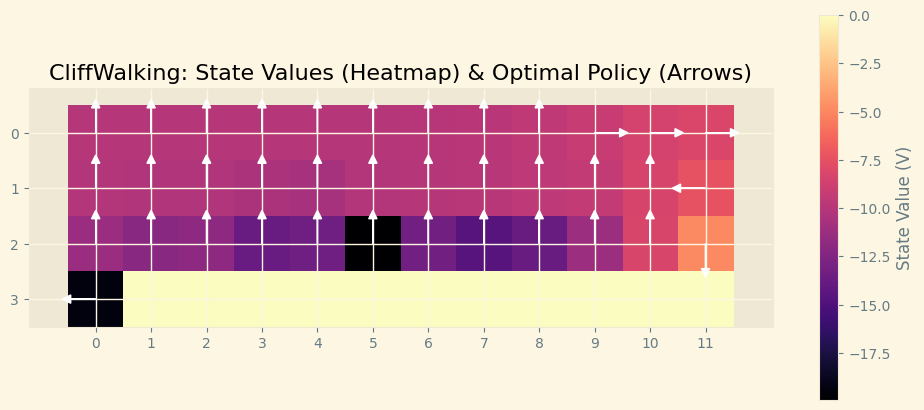

In [68]:
sa_stochastic_q = np.load("../experiments/sarsa_stochastic_q.npy")
plot_q_values_map(sa_stochastic_q)

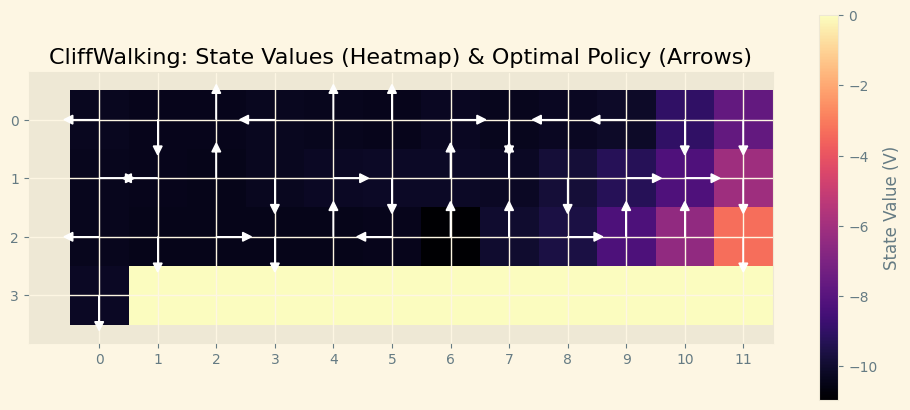

In [69]:
mc_stochastic_q = np.load("../experiments/mc_stochastic_q.npy")
plot_q_values_map(mc_stochastic_q)